# Le Wagon test technique TAs Data Science

Vous disposez de 2h pour compléter ce notebook en expliquant votre démarche et vos observations.
Gérez votre temps comme il vous semble le plus pertinent, la clarté des explication importe autant que la complétion totale du notebook.

**Format de rendu :**
- Lien vers un repository Github public.
- Ce lien devra être envoyé à Laura Mantovi et Agathe Sarran à 12h00.
- Le repository devra contenir votre notebook renommé comme suit : prenom_nom_test_TA_DS.ipynb
- Vous pourrez supprimer ce repository ou le passer en privé à partir de 17h.

Ce notebook doit être éxécutable dans l'environnement virtuel **lewagon** utilisé lors de votre bootcamp.

In [155]:
# ICI seront présent tout les imports utilisées
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression

### Les données

Le fichier **data_weather.csv** comprend des données issues de plusieurs stations météo. Voici un rapide descriptif des colonnes:
- date: date d'enregistrement
- numer_sta: numéro unique de la station
- Latitude: Latitude
- Longitude: Longitude
- Altitude: Altitude
- pmer: pression au niveau de la mer (hpa)
- dd: direction du vent a 10m (sur 360°)
- ff: force du vent a 10m (m/s)
- t: température sous abri (°C)
- u: humidité
- ssfrai: unknown
- rr3: précipitations
- pres: pression à l'altitude de la station  (hpa)
- dd_sin: composante sin de direction du vent
- dd_cos: composante cos de direction du vent

In [5]:
df = pd.read_csv("data/data_weather.csv",
                 header=0,
                 names=["numer_sta", "latitude", "longitude", "altitude", "pmer", "dd", "t", "u", "ssfrai", "rr3", "pres", "dd_sin", "dd_cos"])

##### Data cleaning

Explorez rapidement les données et nettoyez les colonnes qui en ont besoin.<br>Documentez votre code pour expliquer vos choix.

In [ ]:
# Tout d'abord je regarde à quoi ressemble les données
df.head()

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7510.0,44.830667,-0.691333,47.0,99050.0,230.0,9.8,9.6,81.0,0.0,0,98410.0,-0.766044,-0.642788
2010-01-01 03:00:00,7510.0,44.830667,-0.691333,47.0,99160.0,250.0,11.8,8.7,87.0,0.0,0,98520.0,-0.939693,-0.342020
2010-01-01 06:00:00,7510.0,44.830667,-0.691333,47.0,99570.0,290.0,5.1,7.6,91.0,0.0,0,98920.0,-0.939693,0.342020
2010-01-01 09:00:00,7510.0,44.830667,-0.691333,47.0,99990.0,310.0,5.7,6.8,92.0,0.0,0,99340.0,-0.766044,0.642788
2010-01-01 12:00:00,7510.0,44.830667,-0.691333,47.0,100350.0,310.0,6.2,6.6,82.0,0.0,0,99690.0,-0.766044,0.642788


Ici, on peut déduire que notre data représente des données toutes les 3 heures de mesures météorologiques issues de différentes stations. 

In [ ]:
# On peut regarder les différentes
df.describe()

/Users/legregs/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
count,505857.000000,505857.000000,505857.000000,5.058570e+05,505857.000000,505857.000000,505857.000000,505857.000000,505857.000000,505857.000000,505791.000000,5.058570e+05,505857.000000
mean,45.478172,3.451461,193.196708,inf,185.492402,3.417473,13.266307,71.291632,0.000035,0.018035,99359.894818,-7.266871e-02,0.096686
std,1.502581,2.724426,217.479032,NaN,112.882202,2.350552,7.781763,18.898504,0.003194,0.133077,2597.553814,6.482709e-01,0.751743
min,43.437667,-1.608833,2.000000,1.059852e-205,0.000000,0.000000,-19.700000,1.000000,0.000000,0.000000,88160.000000,-1.000000e+00,-1.000000
25%,43.648833,1.175000,26.000000,1.012600e+05,80.000000,1.600000,7.700000,58.000000,0.000000,0.000000,98430.000000,-6.427876e-01,-0.642788
50%,45.726500,3.963167,151.000000,1.017500e+05,190.000000,3.000000,13.000000,74.000000,0.000000,0.000000,99960.000000,-2.449294e-16,0.173648
75%,47.150000,5.216000,263.000000,1.022900e+05,280.000000,4.600000,18.700000,87.000000,0.000000,0.000000,101120.000000,5.000000e-01,0.866025
max,47.614333,7.510000,871.000000,inf,360.000000,23.500000,42.000000,100.000000,0.990000,1.000000,104170.000000,1.000000e+00,1.000000


On voit ici déjà des valeurs aberrantes comme une altitude infinie, une moyenne de l'altitude infini mais aussi un count de pres inférieur à tout les autres.

In [ ]:
# Regardons les informations de ce DF, et on voit que pres contient des valeurs nulles.
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 505857 entries, ('2010-01-01 00:00:00', 7510.0) to ('2021-07-31 21:00:00', 7650.0)
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   numer_sta  505857 non-null  float64
 1   latitude   505857 non-null  float64
 2   longitude  505857 non-null  float64
 3   altitude   505857 non-null  float64
 4   pmer       505857 non-null  float64
 5   dd         505857 non-null  float64
 6   t          505857 non-null  float64
 7   u          505857 non-null  float64
 8   ssfrai     505857 non-null  float64
 9   rr3        505857 non-null  int64  
 10  pres       505791 non-null  float64
 11  dd_sin     505857 non-null  float64
 12  dd_cos     505857 non-null  float64
dtypes: float64(12), int64(1)
memory usage: 53.9+ MB


# Data Cleaning

* Doublons

Commençons par traiter les doublons ! A noter que l'on commence avec 505857 lignes

In [ ]:
# Pour savoir combien de doublons il y a : 89
print(df.duplicated().sum())

# On les retire !
df = df.drop_duplicates()
df.shape # (505768, 13), on a bien perdu 89 lignes

89


(505768, 13)

* Valeurs nulles

On peut maintenant se pencher sur les valeurs nulles

In [ ]:
# On regarde les valeurs nulles, et on retrouve bien les 65 vu précédemment dans pres
print(df.isnull().sum())

numer_sta     0
latitude      0
longitude     0
altitude      0
pmer          0
dd            0
t             0
u             0
ssfrai        0
rr3           0
pres         65
dd_sin        0
dd_cos        0
dtype: int64

In [31]:
# Regardons ces valeurs
df.loc[df['pres'].isna()]

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2018-09-21 03:00:00,7434.0,45.861167,1.175000,402.0,101620.0,250.0,2.2,15.70,90.0,0.0,0,NaN,-9.396926e-01,-0.342020
2018-09-21 06:00:00,7434.0,45.861167,1.175000,402.0,101620.0,240.0,3.9,16.30,93.0,0.0,0,NaN,-8.660254e-01,-0.500000
2010-05-03 15:00:00,7643.0,43.577000,3.963167,2.0,100825.0,10.0,0.0,16.30,51.5,0.0,0,NaN,1.736482e-01,0.984808
2010-11-05 06:00:00,7643.0,43.577000,3.963167,2.0,102965.0,10.0,0.0,14.75,84.0,0.0,0,NaN,1.736482e-01,0.984808
2011-01-30 03:00:00,7643.0,43.577000,3.963167,2.0,101110.0,10.0,0.0,3.35,92.0,0.0,0,NaN,1.736482e-01,0.984808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-03-05 15:00:00,7280.0,47.267833,5.088333,219.0,102110.0,10.0,5.7,11.80,43.0,0.0,0,NaN,1.736482e-01,0.984808
2021-04-28 12:00:00,7280.0,47.267833,5.088333,219.0,100420.0,200.0,1.8,10.50,71.5,0.0,0,NaN,-3.420201e-01,-0.939693
2013-03-17 03:00:00,7299.0,47.614333,7.510000,263.0,100655.0,260.0,0.0,3.85,61.5,0.0,0,NaN,-9.848078e-01,-0.173648
2020-05-18 21:00:00,7299.0,47.614333,7.510000,263.0,102110.0,260.0,0.0,17.95,54.5,0.0,0,NaN,-9.848078e-01,-0.173648


Ici plusieurs options s'offrent à nous: 

- Créer une nouvelle valeur pour ces valeurs nulles, c'est à dire les inpute.
Dans ce cas-ci, je prendrais probablement la moyenne de pres sur la journée.

- La deuxième solution est de supprimer ces lignes. Ces lignes ne réprésentent que 65 valeurs sur 505768, soit environ 0.0001 % des datas. De plus, en observant ces données manquantes ci-dessus, elles semblent rarement ce suivre (hormis les deux premiers).

Ici je vais donc choisir cette seconde option car la perte d'information est minime.

In [ ]:
# Enleve les na de notre jeu de données
df = df.dropna()
df.shape # Shape (505703, 13), on a bien perdu 65 lignes

(505703, 13)

* Outliers 

On peut ici s'intéresser aux outliers, et en particulier à la colonne altitude qu'on a déjà repéré

<Axes: >

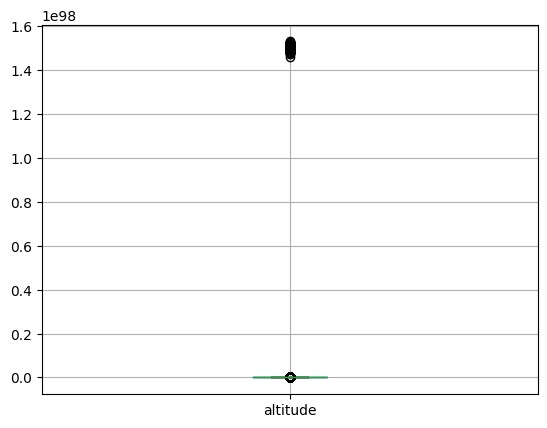

In [ ]:
df[['altitude']].boxplot()

Très bizarre, on a un groupe de données très haut. Essayons de regarder ces données.

In [44]:
df.loc[df['altitude'] > 10000]

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7510.0,44.830667,-0.691333,47.0,99050.0,230.0,9.8,9.6,81.0,0.0,0,98410.0,-0.766044,-6.427876e-01
2010-01-01 03:00:00,7510.0,44.830667,-0.691333,47.0,99160.0,250.0,11.8,8.7,87.0,0.0,0,98520.0,-0.939693,-3.420201e-01
2010-01-01 06:00:00,7510.0,44.830667,-0.691333,47.0,99570.0,290.0,5.1,7.6,91.0,0.0,0,98920.0,-0.939693,3.420201e-01
2010-01-01 09:00:00,7510.0,44.830667,-0.691333,47.0,99990.0,310.0,5.7,6.8,92.0,0.0,0,99340.0,-0.766044,6.427876e-01
2010-01-01 12:00:00,7510.0,44.830667,-0.691333,47.0,100350.0,310.0,6.2,6.6,82.0,0.0,0,99690.0,-0.766044,6.427876e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7650.0,43.437667,5.216000,9.0,100920.0,310.0,3.2,27.2,58.0,0.0,0,100560.0,-0.766044,6.427876e-01
2021-07-31 12:00:00,7650.0,43.437667,5.216000,9.0,100770.0,270.0,6.1,30.6,49.0,0.0,0,100410.0,-1.000000,-1.836970e-16
2021-07-31 15:00:00,7650.0,43.437667,5.216000,9.0,100680.0,310.0,8.2,30.0,40.0,0.0,0,100320.0,-0.766044,6.427876e-01
2021-07-31 18:00:00,7650.0,43.437667,5.216000,9.0,100750.0,320.0,8.0,27.9,45.0,0.0,0,100390.0,-0.642788,7.660444e-01


J'ai ici considéré que l'unité était en mètres, et j'ai donc regardé toutes les stations météos au dessus de 10 000 m d'altitude.

Hors quasiment toutes les données remplissent cette condition !

Deux questions me viennent alors : 
- Quelle est la vraie unité ici ? Impossible de savoir, il faudrait accéder à la source des données ce que je n'ai pas ici
- Comment accéder à tous ces outliers ?

Je vais donc regarder ces outliers à l'aide de l'écart InterQuartile

In [67]:
# Calcule de l'IQR pour l'altitude
IQR_alt = df.altitude.quantile(0.75) - df.altitude.quantile(0.25)

# On regarde les outliers
outliers = df.loc[df['altitude'] > df.altitude.quantile(0.75) + 3*IQR_alt]
outliers

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-15 12:00:00,7591.0,44.565667,6.502333,871.0,1.263193e+43,170.0,2.1,6.0,54.0,0.0,0,91470.0,1.736482e-01,-0.984808
2010-01-22 15:00:00,7591.0,44.565667,6.502333,871.0,1.509188e+98,0.0,0.0,5.8,32.0,0.0,0,91720.0,0.000000e+00,1.000000
2010-01-27 12:00:00,7591.0,44.565667,6.502333,871.0,1.264988e+43,30.0,6.2,6.0,36.0,0.0,0,91600.0,5.000000e-01,0.866025
2010-02-03 15:00:00,7591.0,44.565667,6.502333,871.0,2.776900e+22,210.0,2.1,6.4,31.0,0.0,0,91530.0,-5.000000e-01,-0.866025
2010-02-04 12:00:00,7591.0,44.565667,6.502333,871.0,5.223891e+18,180.0,1.0,6.6,30.0,0.0,0,91520.0,1.224647e-16,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7591.0,44.565667,6.502333,871.0,4.658476e+05,80.0,2.2,23.9,50.0,0.0,0,91280.0,9.848078e-01,0.173648
2021-07-31 12:00:00,7591.0,44.565667,6.502333,871.0,4.274430e+05,190.0,2.7,24.9,52.0,0.0,0,91160.0,-1.736482e-01,-0.984808
2021-07-31 15:00:00,7591.0,44.565667,6.502333,871.0,6.575315e+05,240.0,3.9,20.7,67.0,0.0,0,91080.0,-8.660254e-01,-0.500000
2021-07-31 18:00:00,7591.0,44.565667,6.502333,871.0,1.708415e+06,330.0,3.2,15.8,91.0,0.0,1,91030.0,-5.000000e-01,0.866025


On peut voir ici 23 316 données soit presque 5% des données !

Mais on remarque aussi directement que le numer_sta semble constant !

In [ ]:
outliers.numer_sta.value_counts()

numer_sta
44.565667    23316
Name: count, dtype: int64

C'est donc une station qui a des valeurs d'altitude abberantes ! Et on remarque aussi une longitude anormale.
Supprimons là 😈

In [71]:
sta_bizarre = df.loc[df['numer_sta'] == outliers.numer_sta.iloc[0]]
sta_bizarre

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7591.0,44.565667,6.502333,871.0,7.360564e+00,100.0,1.0,2.5,92.0,0.0,0,89240.0,9.848078e-01,-0.173648
2010-01-01 03:00:00,7591.0,44.565667,6.502333,871.0,4.858421e-02,30.0,6.2,3.6,81.0,0.0,0,88950.0,5.000000e-01,0.866025
2010-01-01 06:00:00,7591.0,44.565667,6.502333,871.0,9.452515e-02,20.0,5.1,3.5,78.0,0.0,0,88810.0,3.420201e-01,0.939693
2010-01-01 09:00:00,7591.0,44.565667,6.502333,871.0,8.115111e-01,30.0,2.1,3.1,88.0,0.0,0,89020.0,5.000000e-01,0.866025
2010-01-01 12:00:00,7591.0,44.565667,6.502333,871.0,1.722905e-31,180.0,3.1,5.3,84.0,0.0,0,89090.0,1.224647e-16,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7591.0,44.565667,6.502333,871.0,4.658476e+05,80.0,2.2,23.9,50.0,0.0,0,91280.0,9.848078e-01,0.173648
2021-07-31 12:00:00,7591.0,44.565667,6.502333,871.0,4.274430e+05,190.0,2.7,24.9,52.0,0.0,0,91160.0,-1.736482e-01,-0.984808
2021-07-31 15:00:00,7591.0,44.565667,6.502333,871.0,6.575315e+05,240.0,3.9,20.7,67.0,0.0,0,91080.0,-8.660254e-01,-0.500000
2021-07-31 18:00:00,7591.0,44.565667,6.502333,871.0,1.708415e+06,330.0,3.2,15.8,91.0,0.0,1,91030.0,-5.000000e-01,0.866025


In [74]:
df_clean = df.loc[df['numer_sta'] != outliers.numer_sta.iloc[0]]
df_clean.describe()

,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
count,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,472039.000000,4.720390e+05,472039.000000
mean,45.543184,3.233757,144.853819,101710.890001,188.969534,3.459701,13.436742,72.042070,0.000038,0.017746,99914.321995,-7.985285e-02,0.094267
std,1.534656,2.690969,124.790641,811.148688,112.210906,2.349357,7.690205,18.524044,0.003307,0.132028,1605.287166,6.546587e-01,0.745762
min,43.437667,-1.608833,2.000000,96260.000000,0.000000,0.000000,-19.700000,1.000000,0.000000,0.000000,92950.000000,-1.000000e+00,-1.000000
25%,43.648833,1.175000,26.000000,101260.000000,90.000000,1.700000,7.900000,59.000000,0.000000,0.000000,98760.000000,-6.427876e-01,-0.642788
50%,45.726500,3.149333,108.000000,101720.000000,190.000000,3.100000,13.200000,75.000000,0.000000,0.000000,100150.000000,-2.449294e-16,0.173648
75%,47.150000,5.088333,235.000000,102210.000000,290.000000,4.600000,18.800000,88.000000,0.000000,0.000000,101190.000000,5.000000e-01,0.866025
max,47.614333,7.510000,402.000000,104690.000000,360.000000,23.500000,42.000000,100.000000,0.990000,1.000000,104170.000000,1.000000e+00,1.000000


On a toujours des valeurs abberrantes pour la longitude...

In [79]:
df_clean.loc[df.longitude > 180.0]

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 06:00:00,7434.0,45.861167,1.175,402.0,99160.0,360.0,3.6,5.5,99.0,0.0,0,94420.0,-2.449294e-16,1.000000
2010-01-01 09:00:00,7434.0,45.861167,1.175,402.0,99760.0,350.0,5.1,1.5,98.0,0.0,0,94920.0,-1.736482e-01,0.984808
2010-01-01 12:00:00,7434.0,45.861167,1.175,402.0,100180.0,340.0,4.1,0.4,99.0,0.0,0,95300.0,-3.420201e-01,0.939693
2010-01-01 15:00:00,7434.0,45.861167,1.175,402.0,100570.0,340.0,4.1,-0.1,99.0,0.0,0,95660.0,-3.420201e-01,0.939693
2010-01-01 18:00:00,7434.0,45.861167,1.175,402.0,101020.0,340.0,4.1,-1.2,97.0,0.0,0,96070.0,-3.420201e-01,0.939693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 21:00:00,7299.0,47.614333,7.510,263.0,101160.0,260.0,3.2,16.1,88.0,0.0,1,97980.0,-9.848078e-01,-0.173648
2010-01-01 00:00:00,7650.0,43.437667,5.216,9.0,98960.0,140.0,5.1,12.7,88.0,0.0,0,98580.0,6.427876e-01,-0.766044
2010-01-01 03:00:00,7650.0,43.437667,5.216,9.0,98770.0,240.0,6.2,10.8,92.0,0.0,0,98390.0,-8.660254e-01,-0.500000
2010-01-01 06:00:00,7650.0,43.437667,5.216,9.0,99010.0,280.0,8.7,8.2,91.0,0.0,0,98630.0,-9.848078e-01,0.173648


Trop de données bizarres ici, je préfère pas y toucher et potentiellement ignore cette variable par la suite

##### Data exploration

Quel est le numéro de la station qui a enregistré le plus de précipitations depuis 2010 ?<br>Dans quelle ville se situe-t-elle ?

In [ ]:
# On regroupe les données par stations en additionnant les précipitations puis on classe de manière décroissante
classement_pluie = df_clean[['rr3','numer_sta']].groupby('numer_sta').sum().sort_values('rr3', ascending = False)
classement_pluie

,rr3
numer_sta,
45.861167,787
44.581167,749
45.726500,732
43.648833,731
44.830667,697
47.150000,627
47.059167,582
47.267833,575
47.614333,571


In [ ]:
# Par curiosité je regarde aussi la station bizarre
sta_bizarre.rr3.sum()

741

In [87]:
# Le gagnant est donc la station 45.861167
df_clean.loc[df_clean['numer_sta'] == 45.861167]

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7434.0,45.861167,1.175,402.0,99080.0,0.0,0.0,6.1,97.0,0.0,1,94360.0,0.000000e+00,1.000000e+00
2010-01-01 03:00:00,7434.0,45.861167,1.175,402.0,99020.0,230.0,2.6,6.2,98.0,0.0,0,94300.0,-7.660444e-01,-6.427876e-01
2010-01-01 06:00:00,7434.0,45.861167,1.175,402.0,99160.0,360.0,3.6,5.5,99.0,0.0,0,94420.0,-2.449294e-16,1.000000e+00
2010-01-01 09:00:00,7434.0,45.861167,1.175,402.0,99760.0,350.0,5.1,1.5,98.0,0.0,0,94920.0,-1.736482e-01,9.848078e-01
2010-01-01 12:00:00,7434.0,45.861167,1.175,402.0,100180.0,340.0,4.1,0.4,99.0,0.0,0,95300.0,-3.420201e-01,9.396926e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7434.0,45.861167,1.175,402.0,101510.0,130.0,1.1,13.4,92.0,0.0,0,96800.0,7.660444e-01,-6.427876e-01
2021-07-31 12:00:00,7434.0,45.861167,1.175,402.0,101440.0,270.0,2.3,16.3,73.0,0.0,0,96780.0,-1.000000e+00,-1.836970e-16
2021-07-31 15:00:00,7434.0,45.861167,1.175,402.0,101330.0,270.0,2.3,19.6,60.0,0.0,0,96720.0,-1.000000e+00,-1.836970e-16
2021-07-31 18:00:00,7434.0,45.861167,1.175,402.0,101340.0,350.0,1.1,16.7,78.0,0.0,0,96690.0,-1.736482e-01,9.848078e-01


On retrouve le problème évoqué précédemment... Longitude invalide.
Regardons donc la deuxieme

In [90]:
# Le second gagnant est donc la station 44.581167
sta_maldives = df_clean.loc[df_clean['numer_sta'] == 44.581167]
sta_maldives

,,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7577.0,44.581167,4.733,73.0,99050.0,360.0,2.1,7.3,96.0,0.0,0,98170.0,-2.449294e-16,1.000000
2010-01-01 03:00:00,7577.0,44.581167,4.733,73.0,98790.0,350.0,5.1,7.7,94.0,0.0,0,97910.0,-1.736482e-01,0.984808
2010-01-01 06:00:00,7577.0,44.581167,4.733,73.0,98840.0,50.0,1.5,7.5,95.0,0.0,1,97960.0,7.660444e-01,0.642788
2010-01-01 09:00:00,7577.0,44.581167,4.733,73.0,99230.0,240.0,1.0,7.6,94.0,0.0,0,98350.0,-8.660254e-01,-0.500000
2010-01-01 12:00:00,7577.0,44.581167,4.733,73.0,99410.0,160.0,0.5,8.3,95.0,0.0,0,98530.0,3.420201e-01,-0.939693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-07-31 09:00:00,7577.0,44.581167,4.733,73.0,101130.0,10.0,5.0,20.8,74.0,0.0,0,100270.0,1.736482e-01,0.984808
2021-07-31 12:00:00,7577.0,44.581167,4.733,73.0,101020.0,20.0,5.3,23.4,62.0,0.0,0,100170.0,3.420201e-01,0.939693
2021-07-31 15:00:00,7577.0,44.581167,4.733,73.0,100890.0,20.0,5.3,24.2,61.0,0.0,0,100040.0,3.420201e-01,0.939693
2021-07-31 18:00:00,7577.0,44.581167,4.733,73.0,101080.0,20.0,3.7,20.4,74.0,0.0,0,100220.0,3.420201e-01,0.939693


En recherchant en ligne la latitude et la longitude, cela correspond aux Maldives ! (South Maalhosmadulu)

Générez un fichier .csv contenant les moyennes des données météo mensuelles pour la station identifiée.

In [120]:
# Je vais ici m'intéresser à la première station valide, donc celle des Maldives
# Je récupère la date avec reset_index et je rename la colonne
pluie_sta_mal = sta_maldives.reset_index()
pluie_sta_mal = pluie_sta_mal.rename(columns={'level_0' : 'date'})
pluie_sta_mal

,date,level_1,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
0,2010-01-01 00:00:00,7577.0,44.581167,4.733,73.0,99050.0,360.0,2.1,7.3,96.0,0.0,0,98170.0,-2.449294e-16,1.000000
1,2010-01-01 03:00:00,7577.0,44.581167,4.733,73.0,98790.0,350.0,5.1,7.7,94.0,0.0,0,97910.0,-1.736482e-01,0.984808
2,2010-01-01 06:00:00,7577.0,44.581167,4.733,73.0,98840.0,50.0,1.5,7.5,95.0,0.0,1,97960.0,7.660444e-01,0.642788
3,2010-01-01 09:00:00,7577.0,44.581167,4.733,73.0,99230.0,240.0,1.0,7.6,94.0,0.0,0,98350.0,-8.660254e-01,-0.500000
4,2010-01-01 12:00:00,7577.0,44.581167,4.733,73.0,99410.0,160.0,0.5,8.3,95.0,0.0,0,98530.0,3.420201e-01,-0.939693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33761,2021-07-31 09:00:00,7577.0,44.581167,4.733,73.0,101130.0,10.0,5.0,20.8,74.0,0.0,0,100270.0,1.736482e-01,0.984808
33762,2021-07-31 12:00:00,7577.0,44.581167,4.733,73.0,101020.0,20.0,5.3,23.4,62.0,0.0,0,100170.0,3.420201e-01,0.939693
33763,2021-07-31 15:00:00,7577.0,44.581167,4.733,73.0,100890.0,20.0,5.3,24.2,61.0,0.0,0,100040.0,3.420201e-01,0.939693
33764,2021-07-31 18:00:00,7577.0,44.581167,4.733,73.0,101080.0,20.0,3.7,20.4,74.0,0.0,0,100220.0,3.420201e-01,0.939693


In [ ]:
# Je transforme la colonne en objet date et je transforme cette colonne pour ne conserver que mois et année
pluie_sta_mal['date'] = pd.to_datetime(pluie_sta_mal['date'])
pluie_sta_mal['date'] = pluie_sta_mal['date'].map(lambda date : f"{str(date.year)}-{str(date.month)}")

In [ ]:
# Je regroupe les données par mois et année et prend la moyenne
pluie_sta_mal_mois = pluie_sta_mal.groupby('date').mean()
pluie_sta_mal_mois

,level_1,numer_sta,latitude,longitude,altitude,pmer,dd,t,u,ssfrai,rr3,pres,dd_sin,dd_cos
date,,,,,,,,,,,,,,
2010-1,7577.0,44.581167,4.733,73.0,101436.270492,161.557377,4.127869,2.567213,79.528689,0.000451,0.008197,100513.483607,0.097451,0.780682
2010-10,7577.0,44.581167,4.733,73.0,101367.701613,128.346774,3.895968,13.417742,70.737903,0.000000,0.048387,100482.016129,0.096490,0.389341
2010-11,7577.0,44.581167,4.733,73.0,100953.291667,101.333333,3.016667,9.017917,77.995833,0.000000,0.025000,100057.500000,0.136618,0.413660
2010-12,7577.0,44.581167,4.733,73.0,101328.709677,96.653226,3.972177,3.944758,78.189516,0.000081,0.044355,100411.733871,0.133349,0.467553
2010-2,7577.0,44.581167,4.733,73.0,100720.758929,177.812500,3.464286,4.884821,74.723214,0.000000,0.031250,99812.723214,-0.003404,0.391333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-3,7577.0,44.581167,4.733,73.0,102283.225806,80.725806,3.698387,9.369355,63.887097,0.000000,0.000000,101375.564516,0.157324,0.507349
2021-4,7577.0,44.581167,4.733,73.0,101716.500000,89.416667,4.006667,11.700833,59.212500,0.000000,0.029167,100821.666667,0.152322,0.415157
2021-5,7577.0,44.581167,4.733,73.0,101573.266129,106.411290,2.824597,15.371774,66.221774,0.000000,0.044355,100691.814516,0.130220,0.376655


In [126]:
# Je peux écrire un csv
pluie_sta_mal_mois.to_csv('données_sta_maldives.csv')


##### Data visualisation - *optionnel*

Pour chaque station d'enregistrement météo, représentez sur un graphique l'évolution de la moyenne mensuelle de la **température** et de l'**humidité** depuis 2010. <br>*La création des graphiques via l'utilisation d'objets **figure** et **axe** est un plus*.

### Approche Machine Learning

##### Modèles

Après avoir obtenu votre `baseline` explorez librement plusieurs algorithmes de Machine Learning pour prédire un événement pluvieux. Pensez à **expliquer votre méthodologie et les différentes étapes de votre raisonnement.**<br>
- sauvegardez vos scores dans un DataFrame `scores_tracking`
- sauvegardez votre meilleur modèle dans un fichier adapté
- enregistrez les paramètres de votre meilleur modèle dans une variable `best_model_params`

*Une attention particulière sera portée à votre méthode de préparation de données, au choix de(s) métrique(s) de performance, à la robustesse de vos scores et à la prévention de l'overfitting.*

# Création target

Pour la target, c'est simplement évenement pluvieux ou non, soit rr3 != 0

In [ ]:
# On vérifie cette inégalité, à noter que int(Bool) renvoie 1 pour True et 0 pour False
y = df_clean['rr3'].map(lambda x : int(x >0))
y

2010-01-01 00:00:00  7510.0    0
2010-01-01 03:00:00  7510.0    0
2010-01-01 06:00:00  7510.0    0
2010-01-01 09:00:00  7510.0    0
2010-01-01 12:00:00  7510.0    0
                              ..
2021-07-31 09:00:00  7650.0    0
2021-07-31 12:00:00  7650.0    0
2021-07-31 15:00:00  7650.0    0
2021-07-31 18:00:00  7650.0    0
2021-07-31 21:00:00  7650.0    0
Name: rr3, Length: 472039, dtype: int64

In [ ]:
# Regardons la répartition de nos données
y.value_counts()

rr3
0    463662
1      8377
Name: count, dtype: int64

On peut voir ici que nos données sont extrèmements inéquilibrés !

# Features

Créons nos features maintenant, j'ai choisi de drop la longitude dû à l'anormalité.
Je ne conserve pas aussi ssfrai car on ne sait pas ce que c'est.  
A l'avenir, cela peut-être intéressant de s'interesser à son potentiel impact.
Je drop aussi numer_sta, car on peut retrouver cette information avec latitude (et idéalement longitude si conservé)

In [141]:
X = df_clean.drop(columns=['rr3', 'longitude', 'ssfrai', 'numer_sta'])

In [142]:
X.head()

,,latitude,altitude,pmer,dd,t,u,pres,dd_sin,dd_cos
2010-01-01 00:00:00,7510.0,-0.691333,99050.0,230.0,9.8,9.6,81.0,98410.0,-0.766044,-0.642788
2010-01-01 03:00:00,7510.0,-0.691333,99160.0,250.0,11.8,8.7,87.0,98520.0,-0.939693,-0.342020
2010-01-01 06:00:00,7510.0,-0.691333,99570.0,290.0,5.1,7.6,91.0,98920.0,-0.939693,0.342020
2010-01-01 09:00:00,7510.0,-0.691333,99990.0,310.0,5.7,6.8,92.0,99340.0,-0.766044,0.642788
2010-01-01 12:00:00,7510.0,-0.691333,100350.0,310.0,6.2,6.6,82.0,99690.0,-0.766044,0.642788


# Scale et split

Il est ici important avant de scale nos données de faire notre train test split.

In [ ]:
# On créer notre jeu test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [149]:
# Par rapidité, j'applique ici robust scaler sur toutes les features
rob_scl = RobustScaler()
# Je fit le Scaler SUR LES DONNEES D'ENTRAINEMENT (Pas de data leakage ici)
rob_scl.fit(X_train)
# Et j'applique sur toutes les données
X_train = rob_scl.transform(X_train)
X_test = rob_scl.transform(X_test)

# Baseline

Une baseline ici peut être de prédire la classe majoritaire, donc qu'il ne pleut jamais.
On pourra comparer nos modèles sur un jeu de validation qu'on va créer ici.

In [ ]:
# Création du jeu d'entrainement et du jeu de validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8)

In [178]:
# Création de notre pred baseline
y_pred_baseline = np.array([0] * len(X_val))

In [179]:
print( f"Accuracy : {(y_pred_baseline == y_val).sum() / len(y_val)}")


Accuracy : 0.9817813152558788


# Logistic Regression

In [166]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [167]:
y_pred_log = log_model.predict(X_val)

In [173]:
(y_pred_log == y_val).sum() / len(y_val)

0.9817056562660775

On fait ici moins biens que la baseline sur l'accuracy.

Pas eu le temps d'aller plus loin

Après avoir généré les valeurs nécessaires à l'affichage de vos **learning curves**, débugguez le code ci-dessous pour produire le graphique attendu.

In [ ]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(test_sizes, test_scores_mean, 'Test score')
plt.ylabel('r2 score', fontsize = 14)
plt.xlabel('Test set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend('center')

##### Etes-vous satifait de ces résultats? Comment les expliqueriez-vous ?


### Approche Deep Learning

Tentez d'améliorer vos prédictions grâce à un modèle de Deep Learning et documentez vos choix.